In [ ]:
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/Colab Notebooks/dataset/train"
test_path = "/content/drive/MyDrive/Colab Notebooks/dataset/test"




In [ ]:
print("Train Classes:", os.listdir(train_path))
print("Test Classes:", os.listdir(test_path))

Train Classes: ['healthy', 'down_syndrome']
Test Classes: ['down_syndrome', 'healthy']


In [ ]:
train_datagen = ImageDataGenerator(
      rescale=1./255,
          rotation_range=20,
              zoom_range=0.2,
                  horizontal_flip=True,
                      validation_split=0.2
                      )


In [ ]:
test_datagen = ImageDataGenerator(
      rescale=1./255
      )



In [ ]:
train_generator = train_datagen.flow_from_directory(
      train_path,
          target_size=(224, 224),
              batch_size=32,
                  class_mode='binary',
                      subset='training'
                      )


Found 984 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
      train_path,
          target_size=(224, 224),
              batch_size=32,
                  class_mode='binary',
                      subset='validation'
                      )


Found 246 images belonging to 2 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
      test_path,
          target_size=(224, 224),
              batch_size=32,
                  class_mode='binary',
                      shuffle=False
                      )


Found 1769 images belonging to 2 classes.


In [ ]:
base_model = ResNet50(
      weights='imagenet',
          include_top=False,
              input_shape=(224, 224, 3)
              )



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
for layer in base_model.layers[:-30]:
      layer.trainable = False

for layer in base_model.layers[-30:]:
      layer.trainable = True

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
      optimizer=Adam(learning_rate=0.00001),
          loss='binary_crossentropy',
              metrics=['accuracy']
              )


In [ ]:
early_stop = EarlyStopping(
      monitor='val_loss',
          patience=5,
              restore_best_weights=True
              )


In [ ]:
history = model.fit(
      train_generator,
          validation_data=val_generator,
              epochs=15,
                  callbacks=[early_stop]
                  )


Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 398s 12s/step - accuracy: 0.6026 - loss: 0.6667 - val_accuracy: 0.5000 - val_loss: 0.7688
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 640ms/step - accuracy: 0.6555 - loss: 0.6233 - val_accuracy: 0.5000 - val_loss: 0.7345
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 658ms/step - accuracy: 0.7002 - loss: 0.5774 - val_accuracy: 0.5000 - val_loss: 0.7213
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 662ms/step - accuracy: 0.7165 - loss: 0.5549 - val_accuracy: 0.5000 - val_loss: 0.7273
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 644ms/step - accuracy: 0.7642 - loss: 0.5034 - val_accuracy: 0.5000 - val_loss: 0.7071
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 707ms/step - accuracy: 0.7368 - loss: 0.5266 - val_accuracy: 0.5569 - val_loss: 0.6789
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 694ms/step - accuracy: 0.7409 - loss: 0.5015 - val_accuracy: 0.6667 - val_loss: 0.6450
Epoch 8/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 724ms/step - accuracy: 0.7673 - loss: 0.4789 - val_accur

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print("\nTest Accuracy:", test_acc * 100, "%")

17/56 ━━━━━━━━━━━━━━━━━━━━ 12:23 19s/step - accuracy: 0.8205 - loss: 0.4173

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


56/56 ━━━━━━━━━━━━━━━━━━━━ 1086s 20s/step - accuracy: 0.7722 - loss: 0.4699

Test Accuracy: 77.21876502037048 %


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)

# True labels
y_true = test_generator.classes

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 215ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.84      0.79       885
           1       0.82      0.70      0.76       884

    accuracy                           0.77      1769
   macro avg       0.78      0.77      0.77      1769
weighted avg       0.78      0.77      0.77      1769

Confusion Matrix:

[[744 141]
 [262 622]]


In [ ]:
model.save("/content/drive/MyDrive/Colab Notebooks/resnet_model.keras")

print("ResNet50 model saved successfully")

ResNet50 model saved successfully


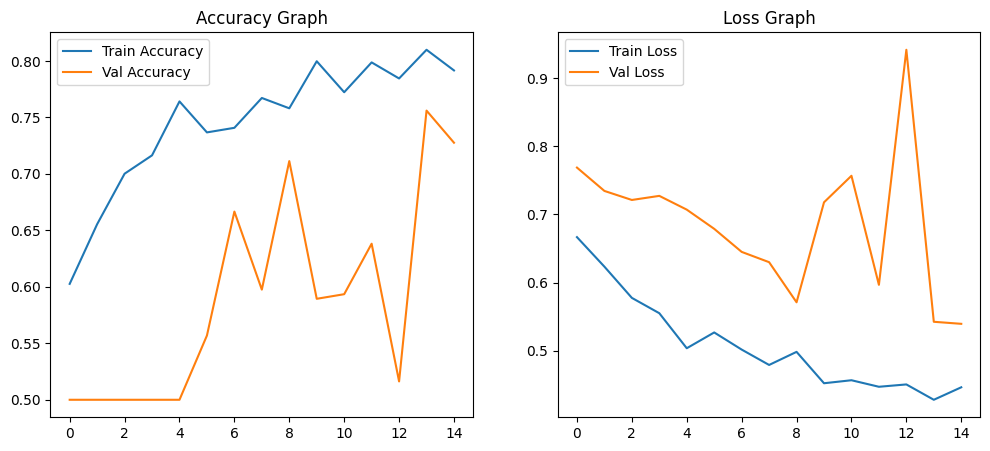

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")

plt.show()

In [1]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

NameError: name 'y_true' is not defined